Submission Criteria
To fulfill the submission requirements for this project, please ensure the following:

Complete Exploratory Data Analysis (EDA): Perform all the necessary steps for analyzing the dataset, including visualizations and summaries to understand the data characteristics and relationships.
Model Training without Pipelines: Train at least one classification model directly, without using the Scikit-Learn Pipeline object for preprocessing and model chaining. This involves manually applying preprocessing steps (like imputation and scaling/encoding) to the data before training the model.
Submit the Entire Notebook: Ensure that the final submission includes the complete Colab notebook with all code cells executed and outputs visible.
Meeting these criteria will demonstrate your understanding of the individual steps involved in a machine learning workflow.

### Import Libraries

In [23]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

### Install Kagglehub

In [24]:
!pip install kagglehub

### Download Dataset (ketangangal/heart-disease-dataset-uci)

In [25]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ketangangal/heart-disease-dataset-uci")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-dataset-uci' dataset.
Path to dataset files: /kaggle/input/heart-disease-dataset-uci


### Download and Load Dataset (redwankarimsony/heart-disease-data)

In [26]:
print("Downloading dataset...")
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")

# Load the dataset from the downloaded path
file_path = f'{path}/heart_disease_uci.csv'
df = pd.read_csv(file_path)

print("Dataset downloaded and loaded successfully.")
print(f"Data shape: {df.shape}")
df.head()

Using Colab cache for faster access to the 'heart-disease-data' dataset.
Dataset downloaded and loaded successfully.
Data shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


### Dataset Information and Missing Values Overview

### Count Missing Values per Column

In [27]:
print("Dataset Information:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isna().sum().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB

Descriptive Statistics:
               id         age    trestbps        chol      thalch     oldpeak  \
co

In [28]:
df.isna().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


### Distribution of Heart Disease Cases

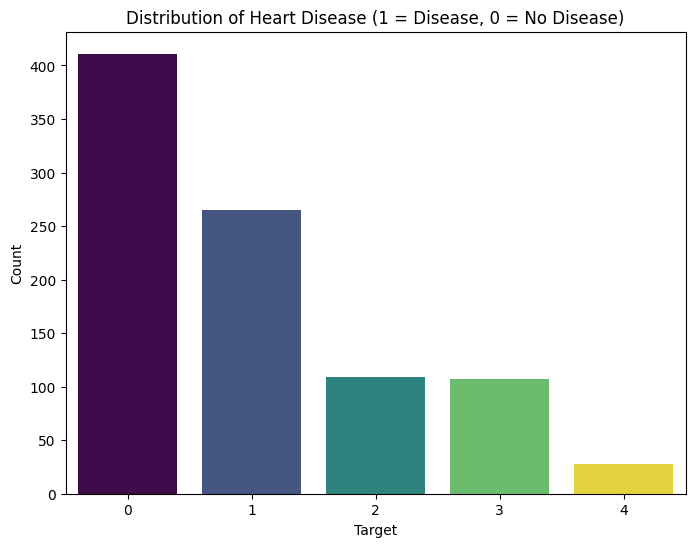

In [29]:
plt.figure(figsize=(8, 6))
sns.countplot(x='num', data=df, palette='viridis', hue='num', legend=False)
plt.title('Distribution of Heart Disease (1 = Disease, 0 = No Disease)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

### Age Distribution vs Heart Disease

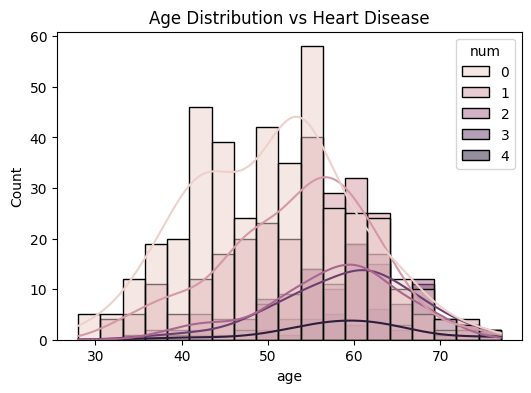

In [30]:
#age vs heart disease
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='age', hue='num', kde=True)
plt.title("Age Distribution vs Heart Disease")
plt.show()

### Gender Distribution vs Heart Disease

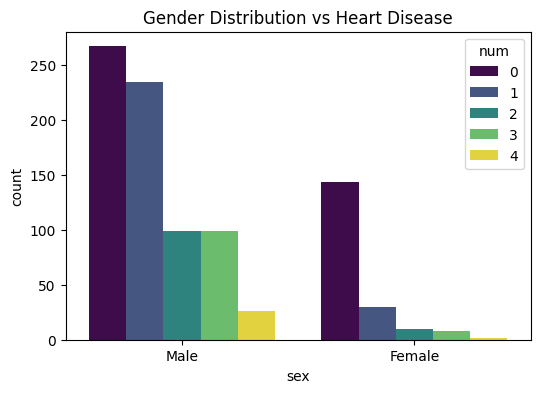

In [31]:
#gender vs heart disease
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sex', hue='num', palette='viridis')
plt.title("Gender Distribution vs Heart Disease")
plt.show()

### Chest Pain Type vs Heart Disease

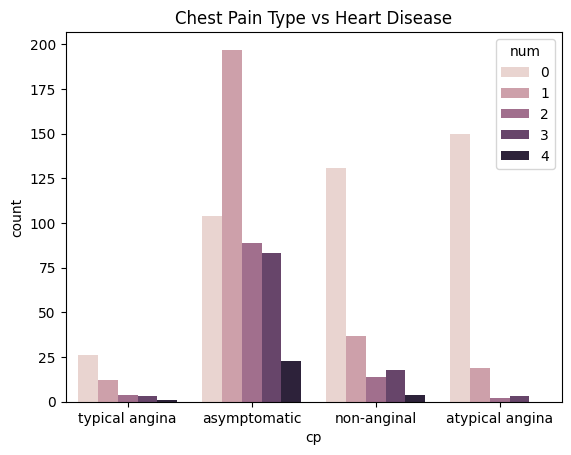

In [32]:
#chest pain
sns.countplot(x='cp', hue='num', data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

### Data Preprocessing: Feature and Target Split

In [33]:
#Data Preprocessing
X = df.drop('num', axis=1)
y = df['num']

### Train-Test Split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### Numerical Feature Scaling and Imputation

### Train Logistic Regression Model

In [35]:
scaler = StandardScaler()

non_numeric_cols = X_train.select_dtypes(include='object').columns
cols_to_drop = list(non_numeric_cols) + ['id']

X_train_numeric = X_train.drop(columns=cols_to_drop)
X_test_numeric = X_test.drop(columns=cols_to_drop)



X_train_numeric = X_train_numeric.fillna(X_train_numeric.mean())
X_test_numeric = X_test_numeric.fillna(X_train_numeric.mean())

X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

### Logistic Regression Predictions

In [36]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [37]:
y_pred_lr = lr.predict(X_test_scaled)

### Evaluate Logistic Regression Model

In [38]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.4782608695652174
[[63 10  1  1  0]
 [30 21  2  1  0]
 [ 9 11  0  5  0]
 [ 6 12  4  4  0]
 [ 1  0  0  3  0]]
              precision    recall  f1-score   support

           0       0.58      0.84      0.68        75
           1       0.39      0.39      0.39        54
           2       0.00      0.00      0.00        25
           3       0.29      0.15      0.20        26
           4       0.00      0.00      0.00         4

    accuracy                           0.48       184
   macro avg       0.25      0.28      0.25       184
weighted avg       0.39      0.48      0.42       184



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Train Random Forest Classifier

In [39]:
#Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_numeric, y_train)

RandomForestClassifier(random_state=42)

### Random Forest Predictions

In [40]:
y_pred_rf = rf.predict(X_test_numeric)

### Evaluate Random Forest Classifier

In [41]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.5380434782608695
[[63  9  2  1  0]
 [20 26  6  2  0]
 [ 6 10  5  4  0]
 [ 6 10  4  5  1]
 [ 1  1  1  1  0]]
              precision    recall  f1-score   support

           0       0.66      0.84      0.74        75
           1       0.46      0.48      0.47        54
           2       0.28      0.20      0.23        25
           3       0.38      0.19      0.26        26
           4       0.00      0.00      0.00         4

    accuracy                           0.54       184
   macro avg       0.36      0.34      0.34       184
weighted avg       0.50      0.54      0.51       184



### Calculate Feature Importance

In [42]:
#Feature Importance
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X_train_numeric.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
3,thalch,0.210591
2,chol,0.198157
0,age,0.195803
4,oldpeak,0.169781
1,trestbps,0.147449
5,ca,0.078220


### Visualize Feature Importance

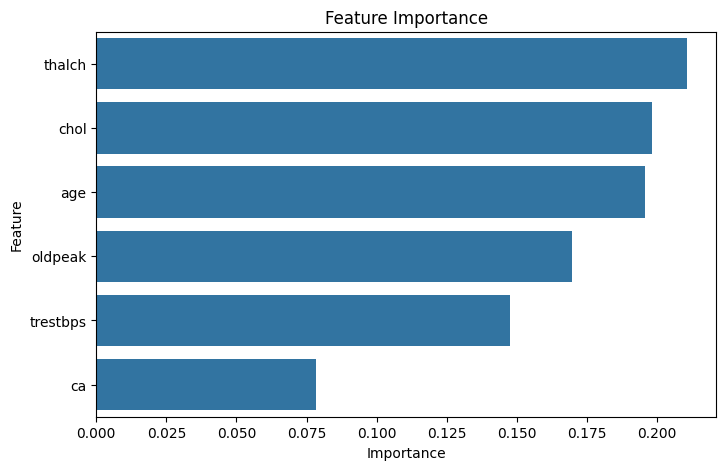

In [43]:
plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=feature_importance)
plt.title("Feature Importance")
plt.show()